## GPT 1D code working fully

t = 0.0421, dt = 1.87e-03
t = 0.0783, dt = 1.78e-03
t = 0.1139, dt = 1.78e-03
t = 0.1496, dt = 1.79e-03
t = 0.1855, dt = 1.80e-03


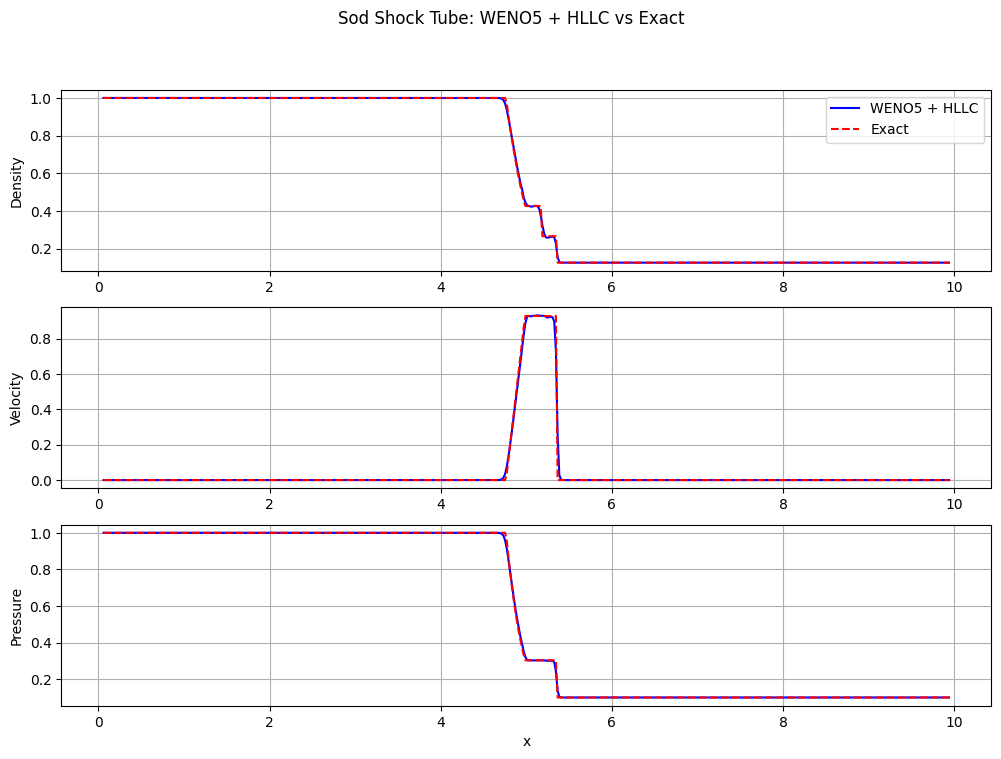

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# PARAMETERS
# ============================================

gamma = 1.4
NX = 500
NG = 3
N = NX + 2*NG

x = np.linspace(0, 10, N)
dx = x[1] - x[0]

CFL = 0.2
t_final = 0.2

EPS = 1e-6

# ============================================
# INITIAL CONDITION (SOD)
# ============================================

U = np.zeros((3, N))

for i in range(N):
    if x[i] < 5:
        rho, u, p = 1.0, 0.0, 1.0
    else:
        rho, u, p = 0.125, 0.0, 0.1

    U[0,i] = rho
    U[1,i] = rho*u
    U[2,i] = p/(gamma-1) + 0.5*rho*u*u

# ============================================
# BOUNDARY CONDITIONS
# ============================================

def apply_bc(U):
    for k in range(3):
        U[k, :NG] = U[k, NG]
        U[k, -NG:] = U[k, -NG-1]

# ============================================
# PRIMITIVES
# ============================================

def primitives(U):
    rho = np.maximum(U[0], EPS)
    u = U[1] / rho
    E = U[2]
    p = (gamma - 1)*(E - 0.5*rho*u*u)
    p = np.maximum(p, EPS)
    return rho, u, p

# ============================================
# WENO5 RECONSTRUCTION (LEFT STATE)
# ============================================

def weno5_left(f):
    N = len(f)
    fL = np.zeros(N)

    for i in range(2, N-2):
        fm2, fm1, f0, fp1, fp2 = f[i-2:i+3]

        beta0 = (13/12)*(fm2 - 2*fm1 + f0)**2 + 0.25*(fm2 - 4*fm1 + 3*f0)**2
        beta1 = (13/12)*(fm1 - 2*f0 + fp1)**2 + 0.25*(fm1 - fp1)**2
        beta2 = (13/12)*(f0 - 2*fp1 + fp2)**2 + 0.25*(3*f0 - 4*fp1 + fp2)**2

        beta0 = max(beta0, 1e-6)
        beta1 = max(beta1, 1e-6)
        beta2 = max(beta2, 1e-6)

        d0, d1, d2 = 0.1, 0.6, 0.3

        a0 = d0/(beta0+EPS)**2
        a1 = d1/(beta1+EPS)**2
        a2 = d2/(beta2+EPS)**2

        s = a0 + a1 + a2

        w0 = a0/s
        w1 = a1/s
        w2 = a2/s

        q0 = (1/3)*fm2 - (7/6)*fm1 + (11/6)*f0
        q1 = -(1/6)*fm1 + (5/6)*f0 + (1/3)*fp1
        q2 = (1/3)*f0 + (5/6)*fp1 - (1/6)*fp2

        fL[i] = w0*q0 + w1*q1 + w2*q2

    return fL

# ============================================
# HLLC FLUX
# ============================================

def hllc_flux(UL, UR):
    rhoL, uL, pL = primitives(UL.reshape(3,1))
    rhoR, uR, pR = primitives(UR.reshape(3,1))

    rhoL, uL, pL = rhoL[0], uL[0], pL[0]
    rhoR, uR, pR = rhoR[0], uR[0], pR[0]

    EL = UL[2]
    ER = UR[2]

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    SL = min(uL - cL, uR - cR)
    SR = max(uL + cL, uR + cR)

    SM = (pR - pL + rhoL*uL*(SL - uL) - rhoR*uR*(SR - uR)) / \
         (rhoL*(SL - uL) - rhoR*(SR - uR) + EPS)

    FL = np.array([rhoL*uL,
                   rhoL*uL**2 + pL,
                   uL*(EL + pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR**2 + pR,
                   uR*(ER + pR)])

    if 0 <= SL:
        return FL
    elif SL <= 0 <= SM:
        rho_star = rhoL*(SL - uL)/(SL - SM + EPS)
        U_star = np.array([
            rho_star,
            rho_star*SM,
            EL/rhoL*rho_star + rho_star*(SM - uL)*(SM + pL/(rhoL*(SL-uL)+EPS))
        ])
        return FL + SL*(U_star - UL)
    elif SM <= 0 <= SR:
        rho_star = rhoR*(SR - uR)/(SR - SM + EPS)
        U_star = np.array([
            rho_star,
            rho_star*SM,
            ER/rhoR*rho_star + rho_star*(SM - uR)*(SM + pR/(rhoR*(SR-uR)+EPS))
        ])
        return FR + SR*(U_star - UR)
    else:
        return FR

# ============================================
# COMPUTE RHS
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    UL = np.zeros((3, N))
    UR = np.zeros((3, N))

    for k in range(3):
        UL[k] = weno5_left(U[k])
        UR[k] = weno5_left(U[k][::-1])[::-1]

    for i in range(2, N-2):
        flux = hllc_flux(UL[:,i], UR[:,i+1])
        rhs[:,i] = -(flux - hllc_flux(UL[:,i-1], UR[:,i])) / dx

    return rhs

# ============================================
# TIME INTEGRATION (RK3)
# ============================================

t = 0.0
step = 0

while t < t_final:

    apply_bc(U)

    rho, u, p = primitives(U)
    c = np.sqrt(gamma*p/rho)
    dt = CFL * dx / np.max(np.abs(u) + c)

    if t + dt > t_final:
        dt = t_final - t

    U1 = U + dt*compute_rhs(U)
    apply_bc(U1)

    U2 = 0.75*U + 0.25*(U1 + dt*compute_rhs(U1))
    apply_bc(U2)

    U = (1/3)*U + (2/3)*(U2 + dt*compute_rhs(U2))

    # positivity fix
    U[0] = np.maximum(U[0], 1e-6)
    U[2] = np.maximum(U[2], 1e-6)

    t += dt
    step += 1

    if step % 20 == 0:
        print(f"t = {t:.4f}, dt = {dt:.2e}")

# ============================================
# EXACT SOLUTION
# ============================================

def exact_sod(x, t, gamma=1.4):
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    # ✅ ADD THIS BLOCK HERE
    if t == 0:
        rho = np.where(x < 5, rhoL, rhoR)
        u = np.where(x < 5, uL, uR)
        p = np.where(x < 5, pL, pR)
        return rho, u, p

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:  # shock
            return (p - p_i) * np.sqrt(A / (p + B))
        else:  # rarefaction
            return (2 * np.sqrt(gamma * p_i / rho) /
                    (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    # Solve p_star
    p = 0.5*(pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR)/dp

        p -= func/df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5*(uL + uR + fR - fL)

    # Speeds
    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    # Left rarefaction
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma*p_star / (rhoL*(p_star/pL)**(1/gamma)))

    # Right shock
    SR = uR + cR * np.sqrt((gamma+1)/(2*gamma)*(p_star/pR - 1) + 1)

    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 5)/t

        if xi < SHL:
            # Left state
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif SHL <= xi <= STL:
            # Rarefaction fan
            u_i = (2/(gamma+1))*(cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)

            rho[i] = rhoL * (c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL * (c_i/cL)**(2*gamma/(gamma-1))

        elif STL < xi < u_star:
            # Left star
            rho[i] = rhoL*(p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif u_star <= xi <= SR:
            # Right star
            rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                            ((gamma-1)/(gamma+1)*p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            # Right state
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out

# ============================================
# PLOT
# ============================================

'''rho, u, p = primitives(U)

plt.figure(figsize=(10,6))
plt.plot(x[NG:-NG], rho[NG:-NG], 'b-', label='WENO5 + HLLC')
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Stable Sod Shock Tube")
plt.grid()
plt.legend()
plt.show()'''

rho_num, u_num, p_num = primitives(U)

# Exact solution
rho_ex, u_ex, p_ex = exact_sod(x, t_final)

x_plot = x[NG:-NG]

plt.figure(figsize=(12,8))

# Density
plt.subplot(3,1,1)
plt.plot(x_plot, rho_num[NG:-NG], 'b-', label='WENO5 + HLLC')
plt.plot(x_plot, rho_ex[NG:-NG], 'r--', label='Exact')
plt.ylabel("Density")
plt.legend()
plt.grid()

# Velocity
plt.subplot(3,1,2)
plt.plot(x_plot, u_num[NG:-NG], 'b-')
plt.plot(x_plot, u_ex[NG:-NG], 'r--')
plt.ylabel("Velocity")
plt.grid()

# Pressure
plt.subplot(3,1,3)
plt.plot(x_plot, p_num[NG:-NG], 'b-')
plt.plot(x_plot, p_ex[NG:-NG], 'r--')
plt.ylabel("Pressure")
plt.xlabel("x")
plt.grid()

plt.suptitle("Sod Shock Tube: WENO5 + HLLC vs Exact")
plt.show()

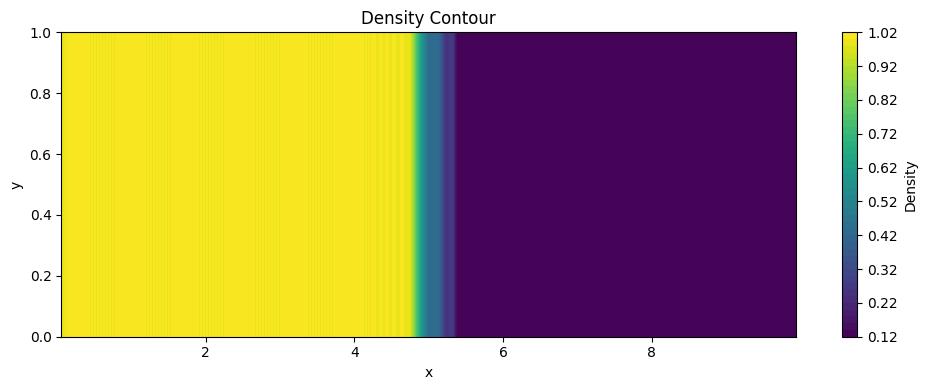

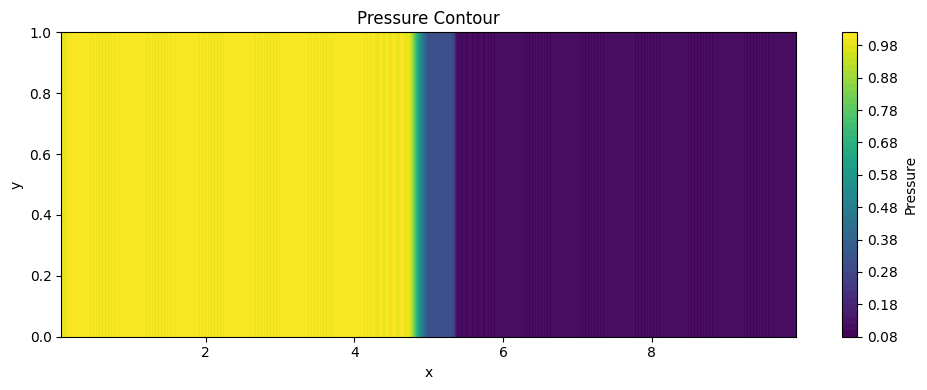

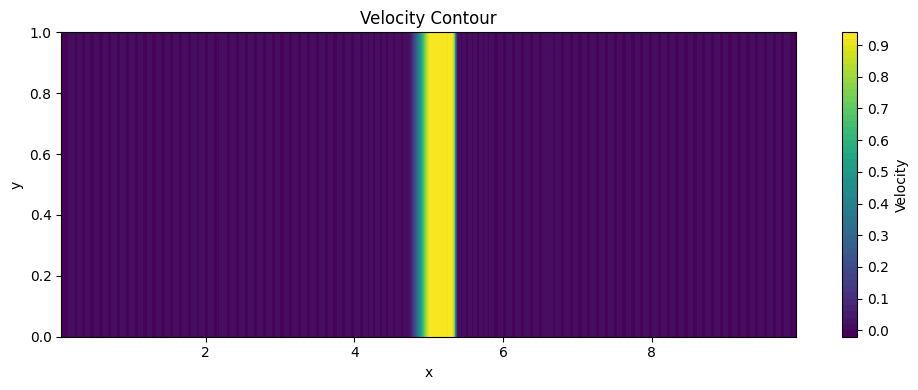

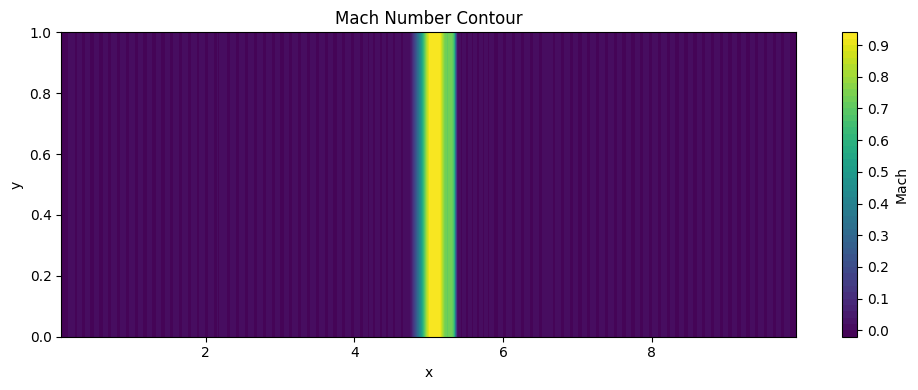

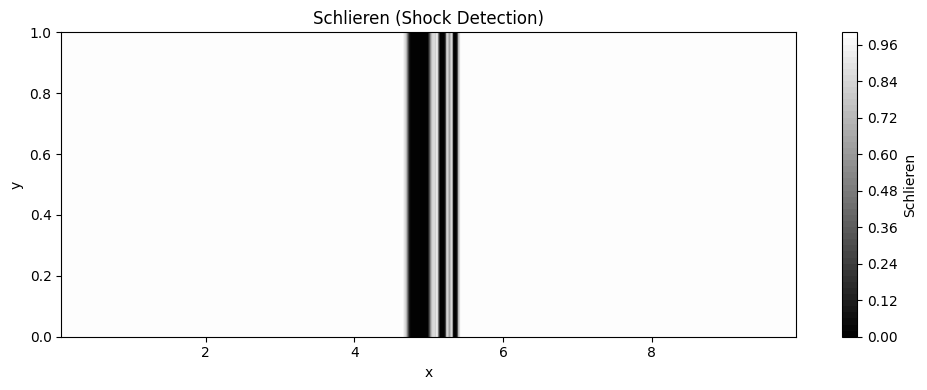

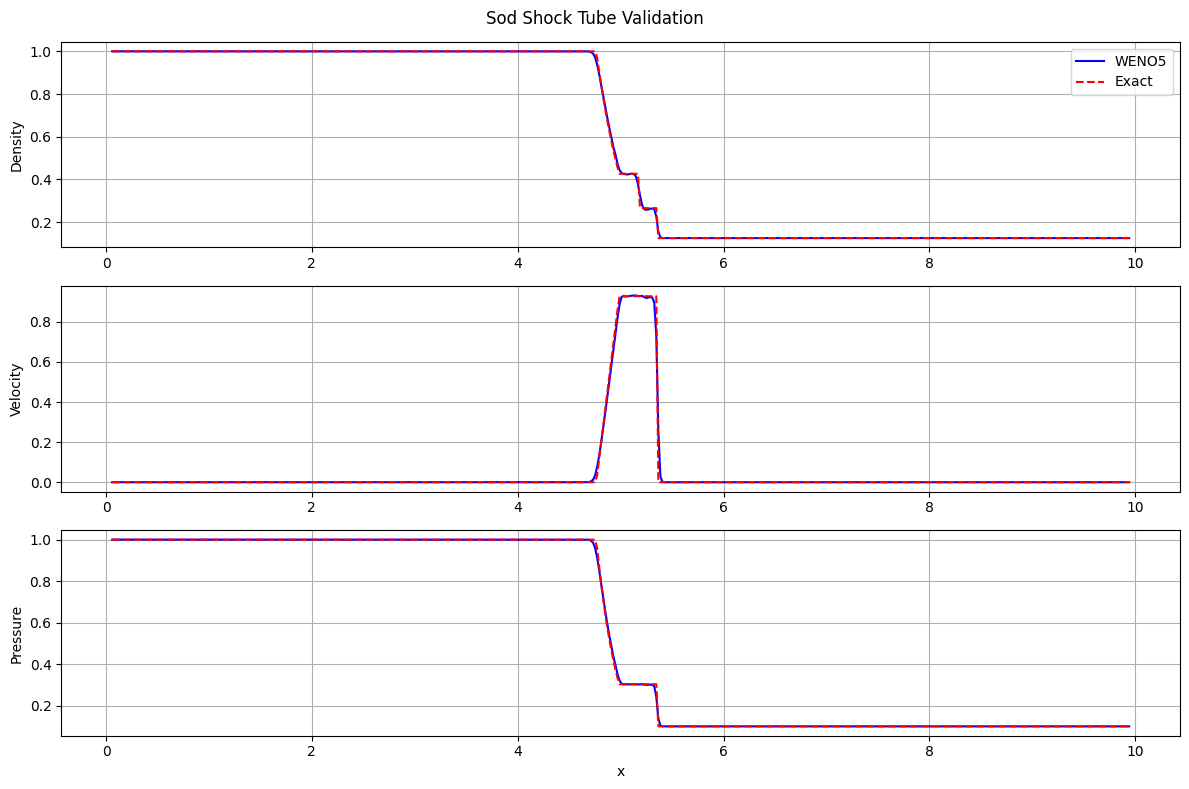

In [ ]:
# Compute derived quantities
rho, u, p = primitives(U)
c = np.sqrt(gamma * p / rho)
Mach = u / c

## Schileren
drho_dx = np.gradient(rho, dx)
schlieren = np.exp(-10 * np.abs(drho_dx) / np.max(np.abs(drho_dx)))

# fake 2D field
NY = 100  # fake height
y = np.linspace(0, 1, NY)

X, Y = np.meshgrid(x[NG:-NG], y)

def make_2D(field):
    return np.tile(field[NG:-NG], (NY, 1))

rho_2D = make_2D(rho)
u_2D   = make_2D(u)
p_2D   = make_2D(p)
M_2D   = make_2D(Mach)
sch_2D = make_2D(schlieren)

# contour plots

## density
plt.figure(figsize=(10,4))
plt.contourf(X, Y, rho_2D, levels=50)
plt.colorbar(label="Density")
plt.title("Density Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## pressure
plt.figure(figsize=(10,4))
plt.contourf(X, Y, p_2D, levels=50)
plt.colorbar(label="Pressure")
plt.title("Pressure Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Velocity
plt.figure(figsize=(10,4))
plt.contourf(X, Y, u_2D, levels=50)
plt.colorbar(label="Velocity")
plt.title("Velocity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Mach number
plt.figure(figsize=(10,4))
plt.contourf(X, Y, M_2D, levels=50)
plt.colorbar(label="Mach")
plt.title("Mach Number Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Schieleren
plt.figure(figsize=(10,4))
plt.contourf(X, Y, sch_2D, levels=50, cmap='gray')
plt.colorbar(label="Schlieren")
plt.title("Schlieren (Shock Detection)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# save validation
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(x_plot, rho_num[NG:-NG], 'b-', label='WENO5')
plt.plot(x_plot, rho_ex[NG:-NG], 'r--', label='Exact')
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(x_plot, u_num[NG:-NG], 'b-')
plt.plot(x_plot, u_ex[NG:-NG], 'r--')
plt.ylabel("Velocity")
plt.grid()

plt.subplot(3,1,3)
plt.plot(x_plot, p_num[NG:-NG], 'b-')
plt.plot(x_plot, p_ex[NG:-NG], 'r--')
plt.ylabel("Pressure")
plt.xlabel("x")
plt.grid()

plt.suptitle("Sod Shock Tube Validation")

plt.tight_layout()
plt.savefig("sod_validation.png", dpi=300)   # ✅ SAVED
plt.show()

## Google gemini code

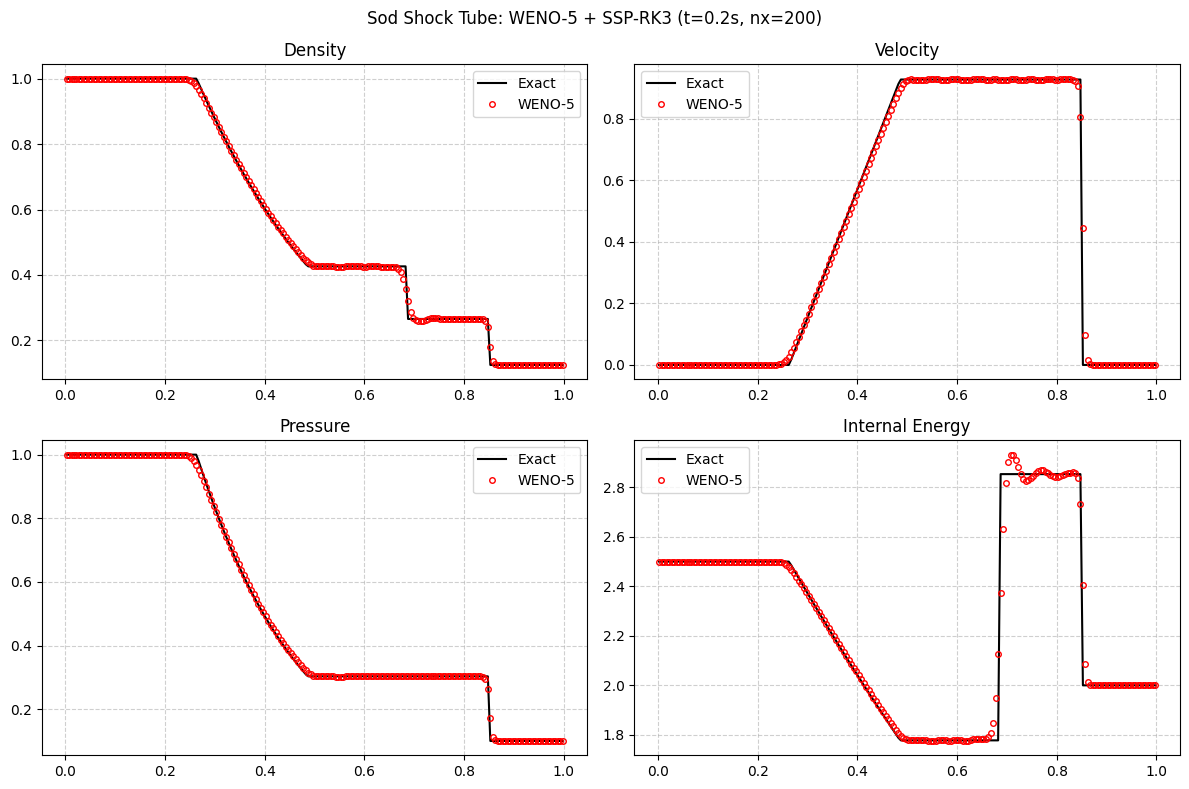

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Setup & Parameters
# ==========================================
gamma = 1.4
nx = 200
x_min, x_max = 0.0, 1.0
dx = (x_max - x_min) / nx
x = np.linspace(x_min + dx/2, x_max - dx/2, nx)
t_final = 0.2
CFL = 0.4
nghost = 3

# ==========================================
# 2. Physics Equations (Euler)
# ==========================================
def cons_to_prim(Q):
    # Added positivity-preserving floors to prevent sqrt NaNs
    rho = np.maximum(Q[0], 1e-7)
    u = Q[1] / rho
    p = (gamma - 1.0) * (Q[2] - 0.5 * rho * u**2)
    p = np.maximum(p, 1e-7)
    return rho, u, p

def prim_to_cons(rho, u, p):
    Q = np.zeros((3, len(rho)))
    Q[0] = rho
    Q[1] = rho * u
    Q[2] = p / (gamma - 1.0) + 0.5 * rho * u**2
    return Q

def compute_flux(Q):
    rho, u, p = cons_to_prim(Q)
    F = np.zeros_like(Q)
    F[0] = rho * u
    F[1] = rho * u**2 + p
    F[2] = u * (Q[2] + p)
    return F

def max_eigenvalue(Q):
    rho, u, p = cons_to_prim(Q)
    c = np.sqrt(gamma * p / rho)
    return np.max(np.abs(u) + c)

# ==========================================
# 3. WENO-5 Reconstruction
# ==========================================
def weno5_reconstruct(v):
    eps = 1e-6

    beta0 = (13/12)*(v[2] - 2*v[3] + v[4])**2 + (1/4)*(3*v[2] - 4*v[3] + v[4])**2
    beta1 = (13/12)*(v[1] - 2*v[2] + v[3])**2 + (1/4)*(v[1] - v[3])**2
    beta2 = (13/12)*(v[0] - 2*v[1] + v[2])**2 + (1/4)*(v[0] - 4*v[1] + 3*v[2])**2

    d0 = 0.3; d1 = 0.6; d2 = 0.1

    alpha0 = d0 / (eps + beta0)**2
    alpha1 = d1 / (eps + beta1)**2
    alpha2 = d2 / (eps + beta2)**2
    sum_alpha = alpha0 + alpha1 + alpha2

    w0 = alpha0 / sum_alpha
    w1 = alpha1 / sum_alpha
    w2 = alpha2 / sum_alpha

    p0 = (1/3)*v[2] + (5/6)*v[3] - (1/6)*v[4]
    p1 = -(1/6)*v[1] + (5/6)*v[2] + (1/3)*v[3]
    p2 = (1/3)*v[0] - (7/6)*v[1] + (11/6)*v[2]

    return w0*p0 + w1*p1 + w2*p2

# ==========================================
# 4. Spatial Derivative & Flux Splitting
# ==========================================
def add_ghost_cells(Q):
    Q_ext = np.zeros((3, nx + 2*nghost))
    Q_ext[:, nghost:-nghost] = Q
    for i in range(nghost):
        Q_ext[:, i] = Q[:, 0]
        Q_ext[:, -i-1] = Q[:, -1]
    return Q_ext

def get_rhs(Q):
    Q_ext = add_ghost_cells(Q)
    F_ext = compute_flux(Q_ext)

    # Add a 10% safety margin to numerical dissipation
    alpha = max_eigenvalue(Q) * 1.1

    F_pos = 0.5 * (F_ext + alpha * Q_ext)
    F_neg = 0.5 * (F_ext - alpha * Q_ext)

    flux = np.zeros((3, nx + 1))

    # FIXED ALIGNMENT: Calculating flux at interface i-1/2
    for i in range(nx + 1):
        for eq in range(3):
            # Positive flux (biased left, centered on i-1)
            idx_p = i + nghost - 1
            v_pos = F_pos[eq, idx_p-2 : idx_p+3]
            f_pos_val = weno5_reconstruct(v_pos)

            # Negative flux (biased right, centered on i)
            idx_n = i + nghost
            v_neg = F_neg[eq, idx_n+2 : idx_n-3 : -1]
            f_neg_val = weno5_reconstruct(v_neg)

            flux[eq, i] = f_pos_val + f_neg_val

    rhs = np.zeros_like(Q)
    for eq in range(3):
        rhs[eq, :] = -(flux[eq, 1:] - flux[eq, :-1]) / dx

    return rhs

# ==========================================
# 5. Exact Riemann Solver (Sod)
# ==========================================
def exact_sod(x, t):
    gamma = 1.4
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1
    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    p_star = 0.3
    for _ in range(20):
        fL = (p_star**( (gamma-1)/(2*gamma) ) - 1) * (2*cL / (gamma-1))
        fR = (p_star - pR) * np.sqrt((2 / (gamma*rhoR)) / (p_star * (gamma+1)/gamma + pR * (gamma-1)/gamma))
        f = fL + fR - (uL - uR)

        dfL = (cL / (gamma*p_star)) * p_star**( (gamma-1)/(2*gamma) )
        A = 2 / (gamma*rhoR)
        B = (gamma+1)/gamma * p_star + (gamma-1)/gamma * pR
        dfR = np.sqrt(A/B) * (1 - (p_star - pR)*(gamma+1)/(2*gamma*B))
        df = dfL + dfR
        p_star -= f / df

    u_star = uL - (p_star**( (gamma-1)/(2*gamma) ) - 1) * (2*cL / (gamma-1))
    rho_star_L = rhoL * (p_star / pL)**(1/gamma)
    rho_star_R = rhoR * (p_star/pR + (gamma-1)/(gamma+1)) / ((gamma-1)/(gamma+1) * p_star/pR + 1)

    S = uR + cR * np.sqrt( (gamma+1)/(2*gamma) * p_star/pR + (gamma-1)/(2*gamma) )

    rho_ex, u_ex, p_ex = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    for i, xi in enumerate(x):
        s = (xi - 0.5) / t
        if s < uL - cL:
            rho_ex[i], u_ex[i], p_ex[i] = rhoL, uL, pL
        elif s < u_star - cL * (p_star/pL)**((gamma-1)/(2*gamma)):
            c_fan = (gamma-1)/(gamma+1) * uL + 2/(gamma+1) * cL - (gamma-1)/(gamma+1) * s
            u_ex[i] = s + c_fan
            p_ex[i] = pL * (c_fan / cL)**(2*gamma/(gamma-1))
            rho_ex[i] = rhoL * (p_ex[i] / pL)**(1/gamma)
        elif s < u_star:
            rho_ex[i], u_ex[i], p_ex[i] = rho_star_L, u_star, p_star
        elif s < S:
            rho_ex[i], u_ex[i], p_ex[i] = rho_star_R, u_star, p_star
        else:
            rho_ex[i], u_ex[i], p_ex[i] = rhoR, uR, pR

    return rho_ex, u_ex, p_ex

# ==========================================
# 6. Main Simulation Loop
# ==========================================
rho = np.where(x < 0.5, 1.0, 0.125)
u   = np.zeros(nx)
p   = np.where(x < 0.5, 1.0, 0.1)
Q   = prim_to_cons(rho, u, p)

t = 0.0
while t < t_final:
    alpha = max_eigenvalue(Q) * 1.1 # Apply margin here too just in case
    dt = CFL * dx / alpha
    if t + dt > t_final:
        dt = t_final - t

    # SSP-RK3 Time Stepping
    rhs1 = get_rhs(Q)
    Q1 = Q + dt * rhs1

    rhs2 = get_rhs(Q1)
    Q2 = 0.75 * Q + 0.25 * Q1 + 0.25 * dt * rhs2

    rhs3 = get_rhs(Q2)
    Q = (1.0/3.0) * Q + (2.0/3.0) * Q2 + (2.0/3.0) * dt * rhs3

    t += dt

# ==========================================
# 7. Post-Processing & Plotting
# ==========================================
rho_num, u_num, p_num = cons_to_prim(Q)
rho_ex, u_ex, p_ex = exact_sod(x, t_final)
e_num = p_num / ((gamma - 1.0) * rho_num)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Sod Shock Tube: WENO-5 + SSP-RK3 (t={t_final}s, nx={nx})")

plots = [(0, 0, rho_ex, rho_num, 'Density'),
         (0, 1, u_ex, u_num, 'Velocity'),
         (1, 0, p_ex, p_num, 'Pressure'),
         (1, 1, p_ex / ((gamma-1)*rho_ex), e_num, 'Internal Energy')]

for r, c, ex, num, title in plots:
    axs[r, c].plot(x, ex, 'k-', label='Exact')
    axs[r, c].plot(x, num, 'ro', markerfacecolor='none', markersize=4, label='WENO-5')
    axs[r, c].set_title(title)
    axs[r, c].grid(True, linestyle='--', alpha=0.6)
    axs[r, c].legend()

plt.tight_layout()
plt.show()

## GPT 2D code

t=0.0042
t=0.0075
t=0.0105
t=0.0134
t=0.0162
t=0.0190
t=0.0217
t=0.0244
t=0.0270
t=0.0296
t=0.0322
t=0.0347
t=0.0373
t=0.0398
t=0.0423
t=0.0448
t=0.0473
t=0.0498
t=0.0523
t=0.0548
t=0.0573
t=0.0598
t=0.0622
t=0.0647
t=0.0672
t=0.0696
t=0.0721
t=0.0745
t=0.0770
t=0.0794
t=0.0818
t=0.0843
t=0.0867
t=0.0891
t=0.0915
t=0.0940
t=0.0964
t=0.0988
t=0.1012
t=0.1036
t=0.1060
t=0.1084
t=0.1108
t=0.1132
t=0.1156
t=0.1180
t=0.1204
t=0.1228
t=0.1251
t=0.1275
t=0.1299
t=0.1323
t=0.1346
t=0.1370
t=0.1394
t=0.1417
t=0.1441
t=0.1465
t=0.1488
t=0.1512
t=0.1536
t=0.1559
t=0.1583
t=0.1606
t=0.1630
t=0.1653
t=0.1677
t=0.1700
t=0.1724
t=0.1747
t=0.1770
t=0.1794
t=0.1817
t=0.1841
t=0.1864
t=0.1887
t=0.1911
t=0.1934
t=0.1957
t=0.1981
t=0.2000


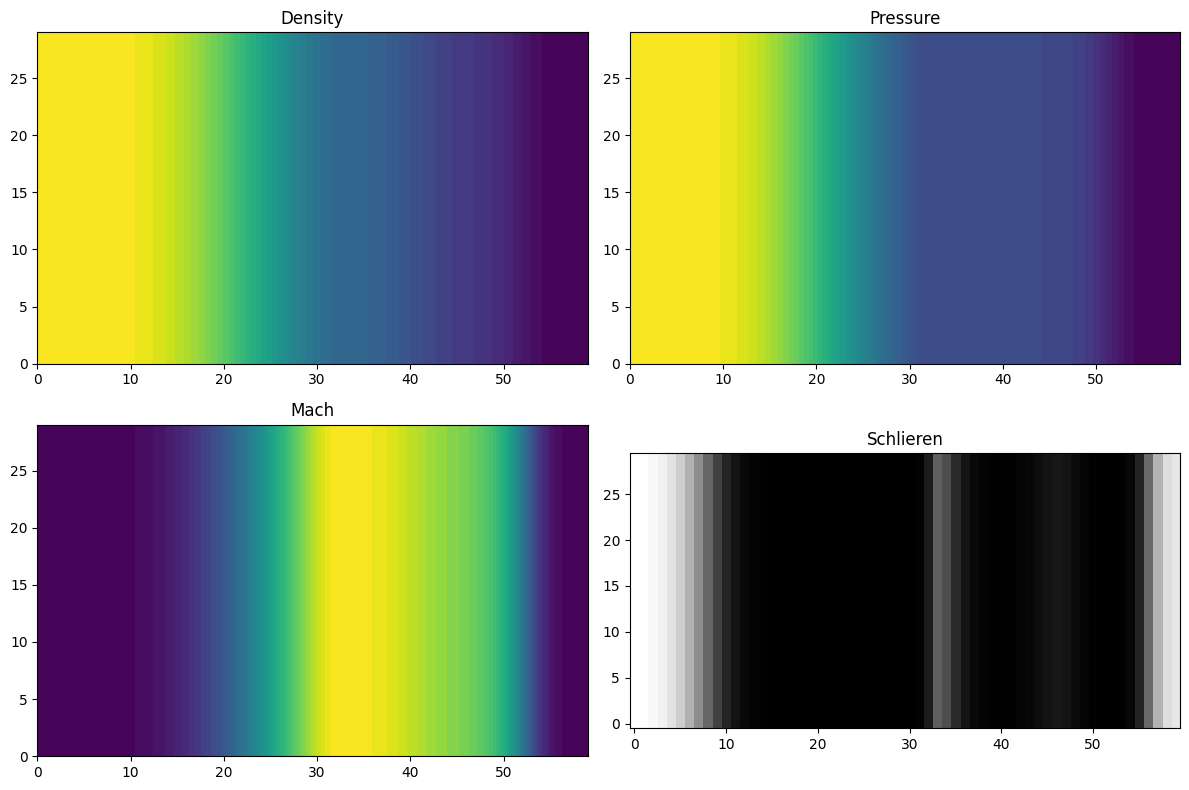

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 1.4
NX, NY =  60, 30
NG = 3

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.3
t_final = 0.2
EPS = 1e-6

# ============================================
# INITIAL CONDITION
# ============================================

U = np.zeros((4, Nx, Ny))

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U[0,i,j] = rho
        U[1,i,j] = rho*u
        U[2,i,j] = rho*v
        U[3,i,j] = p/(gamma-1) + 0.5*rho*(u*u+v*v)

# ============================================
# BC
# ============================================

def apply_bc(U):
    U[:, :NG, :] = U[:, NG:NG+1, :]
    U[:, -NG:, :] = U[:, -NG-1:-NG, :]
    U[:, :, :NG] = U[:, :, NG:NG+1]
    U[:, :, -NG:] = U[:, :, -NG-1:-NG]

# ============================================
# PRIMITIVES
# ============================================

def cons_to_prim(U):
    rho = max(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    E = U[3]
    p = (gamma-1)*(E - 0.5*rho*(u*u+v*v))
    p = max(p, EPS)
    return rho, u, v, p, E

# ============================================
# HLLC (ROBUST VERSION)
# ============================================

def hllc(UL, UR, direction='x'):
    rhoL,uL,vL,pL,EL = cons_to_prim(UL)
    rhoR,uR,vR,pR,ER = cons_to_prim(UR)

    if direction == 'y':
        uL, vL = vL, uL
        uR, vR = vR, uR

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    SL = min(uL - cL, uR - cR)
    SR = max(uL + cL, uR + cR)

    FL = np.array([rhoL*uL,
                   rhoL*uL*uL + pL,
                   rhoL*uL*vL,
                   uL*(EL+pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR*uR + pR,
                   rhoR*uR*vR,
                   uR*(ER+pR)])

    if SL >= 0:
        return FL
    elif SR <= 0:
        return FR
    else:
        return (SR*FL - SL*FR + SL*SR*(UR-UL))/(SR-SL)

# ============================================
# RHS (DIMENSION SPLITTING — STABLE)
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    # X-direction
    for j in range(NG, Ny-NG):
        for i in range(NG, Nx-NG-1):
            flux = hllc(U[:,i,j], U[:,i+1,j], 'x')
            fluxL = hllc(U[:,i-1,j], U[:,i,j], 'x')
            rhs[:,i,j] -= (flux - fluxL)/dx

    # Y-direction
    for i in range(NG, Nx-NG):
        for j in range(NG, Ny-NG-1):
            flux = hllc(U[:,i,j], U[:,i,j+1], 'y')
            fluxL = hllc(U[:,i,j-1], U[:,i,j], 'y')
            rhs[:,i,j] -= (flux - fluxL)/dy

    return rhs

# ============================================
# RK3
# ============================================

t = 0
while t < t_final:
    apply_bc(U)

    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u+v*v))
    c = np.sqrt(gamma*p/rho)

    dt = CFL * min(dx,dy) / np.max(np.abs(u)+np.abs(v)+c)

    if t+dt > t_final:
        dt = t_final - t

    U1 = U + dt*compute_rhs(U)
    apply_bc(U1)

    U2 = 0.75*U + 0.25*(U1 + dt*compute_rhs(U1))
    apply_bc(U2)

    U = (1/3)*U + (2/3)*(U2 + dt*compute_rhs(U2))

    U[0] = np.maximum(U[0], 1e-6)
    U[3] = np.maximum(U[3], 1e-6)

    t += dt
    print(f"t={t:.4f}")

# ============================================
# POST-PROCESSING
# ============================================

rho = U[0, NG:-NG, NG:-NG]
u = U[1, NG:-NG, NG:-NG]/rho
v = U[2, NG:-NG, NG:-NG]/rho
p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u+v*v))
c = np.sqrt(gamma*p/rho)
Mach = np.sqrt(u*u+v*v)/c

# Schlieren
gradx = np.gradient(rho, axis=0)
grady = np.gradient(rho, axis=1)
sch = np.exp(-10*np.sqrt(gradx**2+grady**2)/np.max(np.sqrt(gradx**2+grady**2)))

# ============================================
# PLOTS
# ============================================

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.contourf(rho.T, levels=50)
plt.title("Density")

plt.subplot(2,2,2)
plt.contourf(p.T, levels=50)
plt.title("Pressure")

plt.subplot(2,2,3)
plt.contourf(Mach.T, levels=50)
plt.title("Mach")

plt.subplot(2,2,4)
plt.imshow(sch.T, origin='lower', cmap='gray')
plt.title("Schlieren")

plt.tight_layout()
plt.show()

t=0.0026, rho_mean=0.5625, u_mean=0.0073, p_mean=0.5499
t=0.0047, rho_mean=0.5625, u_mean=0.0119, p_mean=0.5497
t=0.0065, rho_mean=0.5625, u_mean=0.0160, p_mean=0.5495
t=0.0082, rho_mean=0.5625, u_mean=0.0198, p_mean=0.5493
t=0.0099, rho_mean=0.5625, u_mean=0.0233, p_mean=0.5491
t=0.0116, rho_mean=0.5625, u_mean=0.0268, p_mean=0.5488
t=0.0132, rho_mean=0.5625, u_mean=0.0302, p_mean=0.5486
t=0.0148, rho_mean=0.5625, u_mean=0.0336, p_mean=0.5484
t=0.0163, rho_mean=0.5625, u_mean=0.0369, p_mean=0.5481
t=0.0179, rho_mean=0.5625, u_mean=0.0402, p_mean=0.5479
t=0.0194, rho_mean=0.5625, u_mean=0.0435, p_mean=0.5477
t=0.0209, rho_mean=0.5625, u_mean=0.0468, p_mean=0.5475
t=0.0224, rho_mean=0.5625, u_mean=0.0500, p_mean=0.5472
t=0.0239, rho_mean=0.5625, u_mean=0.0532, p_mean=0.5470
t=0.0254, rho_mean=0.5625, u_mean=0.0565, p_mean=0.5468
t=0.0269, rho_mean=0.5625, u_mean=0.0597, p_mean=0.5466
t=0.0284, rho_mean=0.5625, u_mean=0.0630, p_mean=0.5464
t=0.0299, rho_mean=0.5625, u_mean=0.0662, p_mean

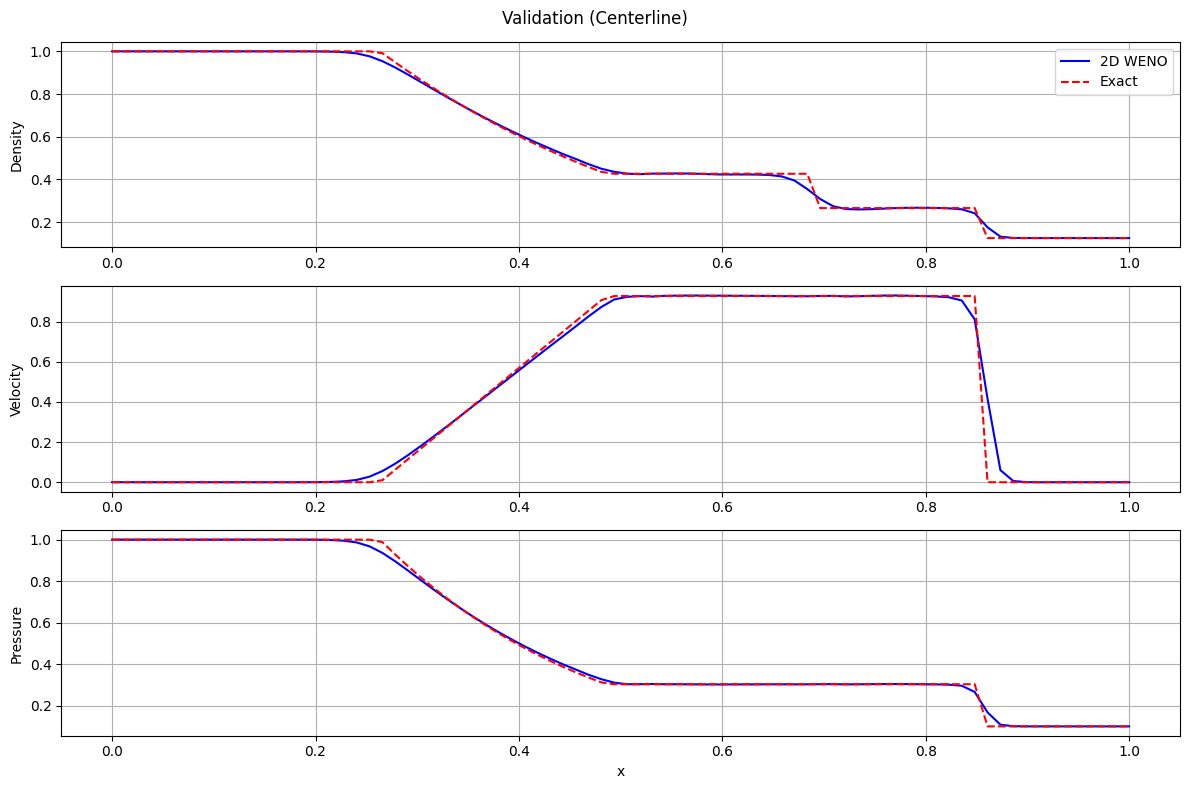

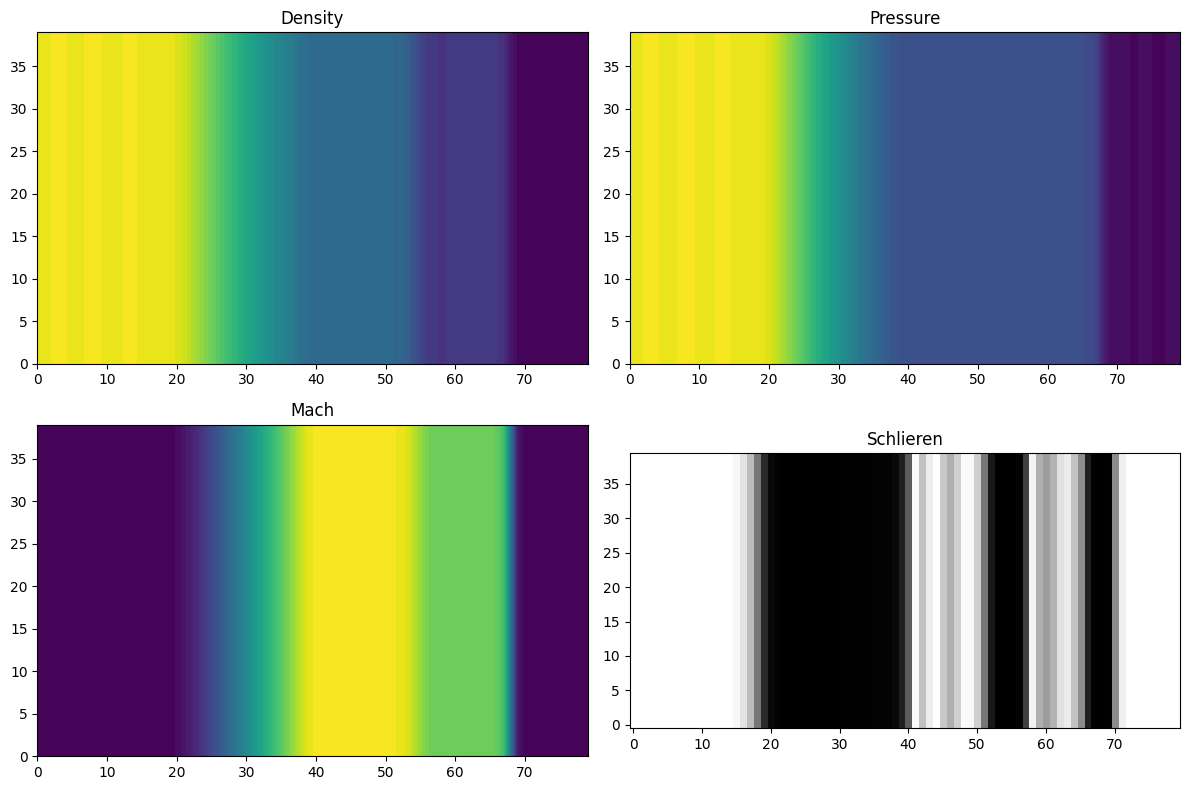

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time


gamma = 1.4
NX, NY = 80, 40
NG = 3

Nx, Ny = NX + 2*NG, NY + 2*NG
dx = 1.0 / NX
dy = 1.0 / NY

CFL = 0.25
t_final = 0.2
EPS = 1e-6

# ============================================
# INITIAL CONDITION
# ============================================

U = np.zeros((4, Nx, Ny))

for i in range(Nx):
    for j in range(Ny):
        if i < Nx//2:
            rho, u, v, p = 1.0, 0.0, 0.0, 1.0
        else:
            rho, u, v, p = 0.125, 0.0, 0.0, 0.1

        U[0,i,j] = rho
        U[1,i,j] = rho*u
        U[2,i,j] = rho*v
        U[3,i,j] = p/(gamma-1) + 0.5*rho*(u*u+v*v)

# ============================================
# BC
# ============================================

def apply_bc(U):
    U[:, :NG, :] = U[:, NG:NG+1, :]
    U[:, -NG:, :] = U[:, -NG-1:-NG, :]
    U[:, :, :NG] = U[:, :, NG:NG+1]
    U[:, :, -NG:] = U[:, :, -NG-1:-NG]

# ============================================
# PRIMITIVES
# ============================================

def cons_to_prim(U):
    rho = max(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    E = U[3]
    p = (gamma-1)*(E - 0.5*rho*(u*u+v*v))
    p = max(p, EPS)
    return rho, u, v, p, E

# ============================================
# WENO5 INTERFACE RECONSTRUCTION
# ============================================

def weno5_left(f):
    N = len(f)
    out = np.zeros(N)

    for i in range(2, N-2):
        fm2, fm1, f0, fp1, fp2 = f[i-2:i+3]

        beta0 = (13/12)*(fm2 - 2*fm1 + f0)**2 + 0.25*(fm2 - 4*fm1 + 3*f0)**2
        beta1 = (13/12)*(fm1 - 2*f0 + fp1)**2 + 0.25*(fm1 - fp1)**2
        beta2 = (13/12)*(f0 - 2*fp1 + fp2)**2 + 0.25*(3*f0 - 4*fp1 + fp2)**2

        d0, d1, d2 = 0.1, 0.6, 0.3

        a0 = d0/(beta0+1e-6)**2
        a1 = d1/(beta1+1e-6)**2
        a2 = d2/(beta2+1e-6)**2

        s = a0+a1+a2

        w0, w1, w2 = a0/s, a1/s, a2/s

        q0 = (1/3)*fm2 - (7/6)*fm1 + (11/6)*f0
        q1 = -(1/6)*fm1 + (5/6)*f0 + (1/3)*fp1
        q2 = (1/3)*f0 + (5/6)*fp1 - (1/6)*fp2

        out[i] = w0*q0 + w1*q1 + w2*q2

    return out

def reconstruct(U_line):
    nvar, N = U_line.shape

    UL = np.zeros((nvar, N))
    UR = np.zeros((nvar, N))

    for k in range(nvar):
        UL[k] = weno5_left(U_line[k])
        UR[k] = weno5_left(U_line[k][::-1])[::-1]

    return UL, UR

# ============================================
# HLLC
# ============================================

def hllc(UL, UR):
    rhoL,uL,vL,pL,EL = cons_to_prim(UL)
    rhoR,uR,vR,pR,ER = cons_to_prim(UR)

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    SL = min(uL-cL, uR-cR)
    SR = max(uL+cL, uR+cR)

    FL = np.array([rhoL*uL,
                   rhoL*uL*uL+pL,
                   rhoL*uL*vL,
                   uL*(EL+pL)])

    FR = np.array([rhoR*uR,
                   rhoR*uR*uR+pR,
                   rhoR*uR*vR,
                   uR*(ER+pR)])

    if SL >= 0: return FL
    if SR <= 0: return FR

    return (SR*FL - SL*FR + SL*SR*(UR-UL))/(SR-SL)

# ============================================
# RHS
# ============================================

def compute_rhs(U):
    rhs = np.zeros_like(U)

    # X
    for j in range(NG, Ny-NG):
        UL, UR = reconstruct(U[:,:,j])

        for i in range(NG, Nx-NG-1):
            F = hllc(UL[:,i], UR[:,i+1])
            FL = hllc(UL[:,i-1], UR[:,i])
            rhs[:,i,j] -= (F-FL)/dx

    # Y
    for i in range(NG, Nx-NG):
        UL, UR = reconstruct(U[:,i,:])

        for j in range(NG, Ny-NG-1):
            ULv = UL[:,j].copy()
            URv = UR[:,j+1].copy()

            ULv[1], ULv[2] = ULv[2], ULv[1]
            URv[1], URv[2] = URv[2], URv[1]

            F = hllc(ULv, URv)

            ULvL = UL[:,j-1].copy()
            URvL = UR[:,j].copy()

            ULvL[1], ULvL[2] = ULvL[2], ULvL[1]
            URvL[1], URvL[2] = URvL[2], URvL[1]

            FL = hllc(ULvL, URvL)

            rhs[:,i,j] -= (F-FL)/dy

    return rhs

# ============================================
# RK3
# ============================================
start_time = time.time()
t = 0
while t < t_final:
    apply_bc(U)

    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    v = U[2]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u+v*v))
    c = np.sqrt(gamma*p/rho)

    dt = CFL * min(dx,dy) / np.max(np.abs(u)+np.abs(v)+c)

    if t+dt > t_final:
        dt = t_final - t

    U1 = U + dt*compute_rhs(U)
    apply_bc(U1)

    U2 = 0.75*U + 0.25*(U1 + dt*compute_rhs(U1))
    apply_bc(U2)

    U = (1/3)*U + (2/3)*(U2 + dt*compute_rhs(U2))

    t += dt
    rho = np.maximum(U[0], EPS)
    u = U[1]/rho
    p = (gamma-1)*(U[3] - 0.5*rho*(u*u))

    rho_mean = np.mean(rho[NG:-NG, NG:-NG])
    u_mean   = np.mean(u[NG:-NG, NG:-NG])
    p_mean   = np.mean(p[NG:-NG, NG:-NG])

    print(f"t={t:.4f}, rho_mean={rho_mean:.4f}, u_mean={u_mean:.4f}, p_mean={p_mean:.4f}")

end_time = time.time()
print("\n==============================")
print(f"Total simulation time: {end_time - start_time:.2f} seconds")
print("==============================")

j_mid = Ny // 2

rho_num = U[0, NG:-NG, j_mid]
u_num   = U[1, NG:-NG, j_mid] / rho_num
p_num   = (gamma-1)*(U[3, NG:-NG, j_mid] - 0.5*rho_num*u_num**2)

x = np.linspace(0, 1, NX)

L1_rho = np.mean(np.abs(rho_num - rho_ex))
print(f"L1 Error (Density): {L1_rho:.6f}")

# ============================================
# EXACT SOLUTION
# ============================================

'''def exact_sod(x, t, gamma=1.4):
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    # ✅ ADD THIS BLOCK HERE
    if t == 0:
        rho = np.where(x < 5, rhoL, rhoR)
        u = np.where(x < 5, uL, uR)
        p = np.where(x < 5, pL, pR)
        return rho, u, p

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:  # shock
            return (p - p_i) * np.sqrt(A / (p + B))
        else:  # rarefaction
            return (2 * np.sqrt(gamma * p_i / rho) /
                    (gamma - 1)) * ((p / p_i)**((gamma - 1)/(2*gamma)) - 1)

    # Solve p_star
    p = 0.5*(pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR)/dp

        p -= func/df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5*(uL + uR + fR - fL)

    # Speeds
    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    # Left rarefaction
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma*p_star / (rhoL*(p_star/pL)**(1/gamma)))

    # Right shock
    SR = uR + cR * np.sqrt((gamma+1)/(2*gamma)*(p_star/pR - 1) + 1)

    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 5)/t

        if xi < SHL:
            # Left state
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif SHL <= xi <= STL:
            # Rarefaction fan
            u_i = (2/(gamma+1))*(cL + xi)
            c_i = cL - (gamma-1)/2 * (u_i - uL)

            rho[i] = rhoL * (c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL * (c_i/cL)**(2*gamma/(gamma-1))

        elif STL < xi < u_star:
            # Left star
            rho[i] = rhoL*(p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif u_star <= xi <= SR:
            # Right star
            rho[i] = rhoR * ((p_star/pR + (gamma-1)/(gamma+1)) /
                            ((gamma-1)/(gamma+1)*p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            # Right state
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out'''

def exact_sod(x, t, gamma=1.4):
    rhoL, uL, pL = 1.0, 0.0, 1.0
    rhoR, uR, pR = 0.125, 0.0, 0.1

    def f(p, rho, p_i):
        A = 2 / ((gamma + 1) * rho)
        B = (gamma - 1) / (gamma + 1) * p_i

        if p > p_i:
            return (p - p_i) * np.sqrt(A / (p + B))
        else:
            return (2*np.sqrt(gamma*p_i/rho)/(gamma-1)) * \
                   ((p/p_i)**((gamma-1)/(2*gamma)) - 1)

    # Solve p_star
    p = 0.5*(pL + pR)
    for _ in range(50):
        fL = f(p, rhoL, pL)
        fR = f(p, rhoR, pR)
        func = fL + fR + uR - uL

        dp = 1e-6
        df = (f(p+dp, rhoL, pL) + f(p+dp, rhoR, pR) - fL - fR)/dp

        p -= func/df
        p = max(p, 1e-6)

    p_star = p
    u_star = 0.5*(uL + uR + fR - fL)

    cL = np.sqrt(gamma*pL/rhoL)
    cR = np.sqrt(gamma*pR/rhoR)

    # Wave speeds
    SHL = uL - cL
    STL = u_star - np.sqrt(gamma*p_star / (rhoL*(p_star/pL)**(1/gamma)))
    SR  = uR + cR*np.sqrt((gamma+1)/(2*gamma)*(p_star/pR - 1) + 1)

    rho = np.zeros_like(x)
    u = np.zeros_like(x)
    p_out = np.zeros_like(x)

    for i in range(len(x)):
        xi = (x[i] - 0.5)/t

        if xi < SHL:
            rho[i], u[i], p_out[i] = rhoL, uL, pL

        elif SHL <= xi <= STL:
            # rarefaction
            u_i = (2/(gamma+1))*(cL + xi)
            c_i = cL - (gamma-1)/2*(u_i - uL)

            rho[i] = rhoL*(c_i/cL)**(2/(gamma-1))
            u[i] = u_i
            p_out[i] = pL*(c_i/cL)**(2*gamma/(gamma-1))

        elif STL < xi < u_star:
            rho[i] = rhoL*(p_star/pL)**(1/gamma)
            u[i] = u_star
            p_out[i] = p_star

        elif u_star <= xi <= SR:
            rho[i] = rhoR*((p_star/pR + (gamma-1)/(gamma+1)) /
                           ((gamma-1)/(gamma+1)*p_star/pR + 1))
            u[i] = u_star
            p_out[i] = p_star

        else:
            rho[i], u[i], p_out[i] = rhoR, uR, pR

    return rho, u, p_out


# ============================================
# PLOT
# ============================================

rho_ex, u_ex, p_ex = exact_sod(x, t_final)

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(x, rho_num, 'b-', label='2D WENO')
plt.plot(x, rho_ex, 'r--', label='Exact')
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(x, u_num, 'b-')
plt.plot(x, u_ex, 'r--')
plt.ylabel("Velocity")
plt.grid()

plt.subplot(3,1,3)
plt.plot(x, p_num, 'b-')
plt.plot(x, p_ex, 'r--')
plt.ylabel("Pressure")
plt.xlabel("x")
plt.grid()

plt.suptitle("Validation (Centerline)")

plt.tight_layout()
plt.savefig("validation.png", dpi=300)
plt.show()


rho = U[0, NG:-NG, NG:-NG]
u = U[1, NG:-NG, NG:-NG]/rho
v = U[2, NG:-NG, NG:-NG]/rho
p = (gamma-1)*(U[3, NG:-NG, NG:-NG] - 0.5*rho*(u*u+v*v))
c = np.sqrt(gamma*p/rho)
Mach = np.sqrt(u*u+v*v)/c

gradx = np.gradient(rho, axis=0)
grady = np.gradient(rho, axis=1)
sch = np.log10(-10*np.sqrt(gradx**2+grady**2)/np.max(np.sqrt(gradx**2+grady**2)))

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.contourf(rho.T, levels=50)
plt.title("Density")

plt.subplot(2,2,2)
plt.contourf(p.T, levels=50)
plt.xlabel("x")
plt.title("Pressure")

plt.subplot(2,2,3)
plt.contourf(Mach.T, levels=50)
plt.title("Mach")

plt.subplot(2,2,4)
plt.imshow(sch.T, origin='lower', cmap='gray')
plt.title("Schlieren")

plt.tight_layout()
plt.show()